# Step 4: Final Optimized Cross-Task Evaluation

This version removes all manual re-implementations of sliding windows and metric math. It treats the `eomt` repository as a library, calling the same internal methods used by the training CLI.

In [1]:
!pip install lightning > /dev/null

In [9]:
!pip install gitignore_parser > /dev/null

In [ ]:
!pip install -U 'jsonargparse[signatures]>=4.27.7' >/dev/null

In [2]:
from google.colab import drive
import os
import sys
import yaml
import torch
import importlib
import torch.nn.functional as F
import matplotlib.pyplot as plt
from tqdm import tqdm
from lightning import seed_everything

# 1. Environment Configuration
drive.mount('/content/drive')
project_root = '/content/drive/MyDrive/FundGitHubProject'
eomt_folder = project_root + '/eomt'

os.chdir(project_root)
if project_root not in sys.path:
    sys.path.insert(0, project_root)
if eomt_folder not in sys.path:
    sys.path.insert(0, eomt_folder) # Insert at the beginning to override pre-installed 'datasets'

from eval.iouEval import iouEval

seed_everything(0, verbose=False)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Active Device: {device}")

Mounted at /content/drive
Active Device: cuda


In [ ]:
import sys
import os
import importlib
import yaml
import torch

def load_project_model(config_path, checkpoint_path):
    with open(config_path, "r") as f: cfg = yaml.safe_load(f)

    # A. Setup Data (Extract metadata like img_size)
    d_mod, d_cls = cfg["data"]["class_path"].rsplit(".", 1)
    if not d_mod.startswith("eomt."):
        d_mod = f"eomt.{d_mod}"
    dm = getattr(importlib.import_module(d_mod), d_cls)(path="eomt/data", batch_size=1, num_workers=0, **cfg["data"].get("init_args", {}))

    # B. Setup Model (Recursive build of Encoder -> Network -> LightningModule)
    m_mod, m_cls = cfg["model"]["class_path"].rsplit(".", 1)
    if not m_mod.startswith("eomt."):
        m_mod = f"eomt.{m_mod}"
    net_args = cfg["model"]["init_args"]["network"]

    from eomt.models.vit import ViT
    from eomt.models.eomt import EoMT

    encoder = ViT(img_size=dm.img_size, **net_args["init_args"]["encoder"]["init_args"])
    network = EoMT(encoder=encoder, num_classes=dm.num_classes, **{k:v for k,v in net_args["init_args"].items() if k != "encoder"})

    # Extract extra dataset-specific arguments safely from the yaml config!
    def find_key(d, target_key):
        if isinstance(d, dict):
            if target_key in d:
                return d[target_key]
            for k, v in d.items():
                res = find_key(v, target_key)
                if res is not None:
                    return res
        return None

    extra_args = {}
    sc_from_cfg = find_key(cfg, "stuff_classes")
    if sc_from_cfg is not None:
        extra_args["stuff_classes"] = sc_from_cfg
    elif hasattr(dm, "stuff_classes"):
        extra_args["stuff_classes"] = dm.stuff_classes

    model = getattr(importlib.import_module(m_mod), m_cls)(
        network=network, img_size=dm.img_size, num_classes=dm.num_classes,
        **extra_args,
        **{k:v for k,v in cfg["model"]["init_args"].items() if k != "network"}
    )

    # C. State Dict Injection
    ckpt = torch.load(checkpoint_path, map_location="cpu")
    model.load_state_dict(ckpt.get("state_dict", ckpt), strict=False)
    return model.to(device).eval(), dm

# Updated the checkpoint path to look for the .bin format!
model_cs, dm_cs = load_project_model("eomt/configs/dinov2/cityscapes/semantic/eomt_base_640.yaml", "eomt/eomt_weights/eomt_cityscapes.bin")
model_coco, _ = load_project_model("eomt/configs/dinov2/coco/panoptic/eomt_base_640_2x.yaml", "eomt/eomt_weights/eomt_coco.bin")

/usr/local/lib/python3.12/dist-packages/lightning/pytorch/utilities/parsing.py:213: Attribute 'network' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['network'])`.


## 2. Visualization (High-Level Methods)
We use the framework's internal `window_imgs_semantic` and `resize_and_pad_imgs_instance_panoptic` to visualize the same image through two different task lenses.

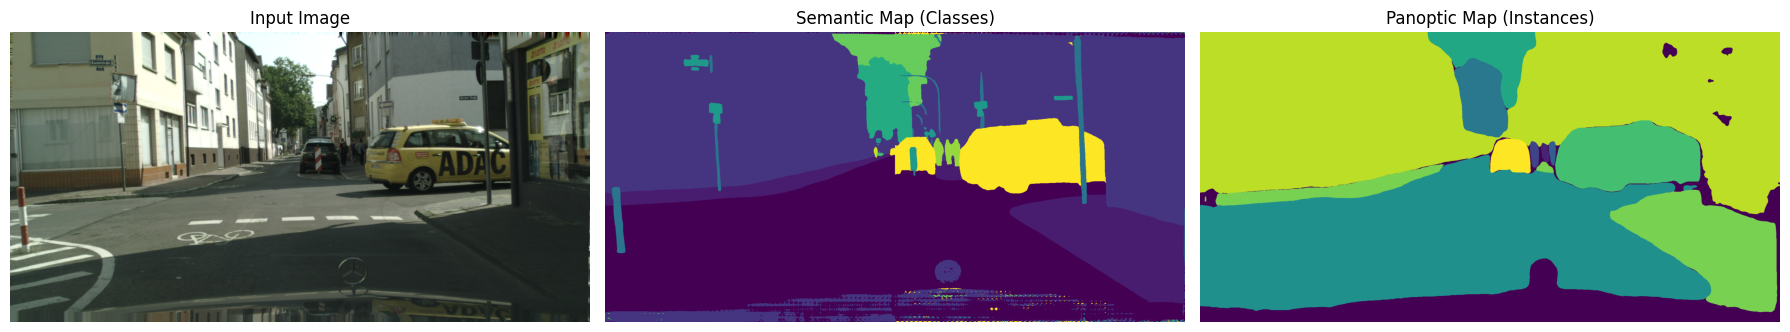

In [ ]:
dm_cs.setup(); img, _ = dm_cs.cityscapes_val_dataset[0]
orig_size = img.shape[-2:]

with torch.no_grad():
    # 1. Cityscapes Semantic (Sliding Window)
    crops, origins = model_cs.window_imgs_semantic([img])
    m_l, c_l = model_cs(crops.to(device))
    m_l = F.interpolate(m_l[-1], model_cs.img_size, mode="bilinear")
    crop_logits = model_cs.to_per_pixel_logits_semantic(m_l, c_l[-1])
    pred_cs = model_cs.revert_window_logits_semantic(crop_logits, origins, [orig_size])[0].argmax(0)

    # 2. COCO Panoptic (Padded Resize)
    tx = model_coco.resize_and_pad_imgs_instance_panoptic([img.to(device)])
    mp, cp = model_coco(tx)
    mp = model_coco.revert_resize_and_pad_logits_instance_panoptic(F.interpolate(mp[-1], model_coco.img_size, mode="bilinear"), [orig_size])
    pred_coco = model_coco.to_per_pixel_preds_panoptic(mp, cp[-1], model_coco.stuff_classes, 0.8, 0.8)[0]

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
axes[0].imshow(img.permute(1, 2, 0).numpy()); axes[0].set_title("Input Image")
axes[1].imshow(pred_cs.cpu().numpy()); axes[1].set_title("Semantic Map (Classes)")
axes[2].imshow(pred_coco[..., 1].cpu().numpy()); axes[2].set_title("Panoptic Map (Instances)")
for ax in axes: ax.axis("off")
plt.tight_layout(); plt.show()

## 3. The Semantic Bridge (Quantitative Mapping)
We consolidate the `bridge` and `stuff_bridge` into a single translation function. We evaluate on 19 classes, treating everything else as class ID 19 (Ignore).

In [ ]:
# Load the index translation (0-79 model index -> 1-91 COCO ID)
import json
map_file_path = os.path.join(project_root, 'coco-classes-mapping-master/coco_mapping_80to91.json')
with open(map_file_path, 'r') as f: coco_idx_map = {int(k)-1: int(v) for k, v in json.load(f).items()}

# Build the final bridge (COCO IDs -> Cityscapes Train IDs)
things_map = { 1: 11, 2: 18, 3: 13, 4: 17, 6: 15, 7: 16, 8: 14, 10: 6, 13: 7 }
stuff_map = { 100: 0, 123: 1, 91: 2, 129: 2, 109: 3, 110: 3, 111: 3, 112: 3, 131: 3, 117: 4, 116: 8, 125: 8, 126: 9, 119: 10 }

def bridge_to_cs(pred_tensor):
    res = torch.full_like(pred_tensor, 19)
    for idx, coco_id in coco_idx_map.items():
        if coco_id in things_map: res[pred_tensor == idx] = things_map[coco_id]
    for stuff_id, cs_id in stuff_map.items():
        res[pred_tensor == stuff_id] = cs_id
    return res

evaluator = iouEval(20) # 19 classes + 1 ignore bucket
for batch in tqdm(dm_cs.val_dataloader(), desc="Evaluating Mapped COCO"):
    imgs, targets = batch
    gt = model_cs.to_per_pixel_targets_semantic(targets, 19)[0].to(device) # High-level framework GT conversion

    with torch.no_grad():
        # Predict using COCO model
        tx = model_coco.resize_and_pad_imgs_instance_panoptic([imgs[0].to(device)])
        mp, cp = model_coco(tx)
        mp = model_coco.revert_resize_and_pad_logits_instance_panoptic(F.interpolate(mp[-1], model_coco.img_size, mode="bilinear"), [imgs[0].shape[-2:]])
        pred = model_coco.to_per_pixel_preds_panoptic(mp, cp[-1], model_coco.stuff_classes, 0.8, 0.8)[0][..., 0]

        # Bridge and Eval
        evaluator.addBatch(bridge_to_cs(pred).unsqueeze(0).unsqueeze(0), gt.unsqueeze(0).unsqueeze(0))

_, ious = evaluator.getIoU()
print(f"\nZero-Shot COCO mIoU on Cityscapes: {ious[:19].mean()*100:.2f}%")

Evaluating Mapped COCO: 100%|██████████| 500/500 [07:30<00:00,  1.11it/s]


Zero-Shot COCO mIoU on Cityscapes: 45.93%


In [20]:
import torch

# Wrap raw weights into a valid PyTorch Lightning checkpoint format
bin_path = "eomt/eomt_weights/eomt_cityscapes.bin"
ckpt_path = "eomt/eomt_weights/eomt_cityscapes.ckpt"

raw_ckpt = torch.load(bin_path, map_location="cpu")
pl_ckpt = {
    "state_dict": raw_ckpt.get("state_dict", raw_ckpt),
    "pytorch-lightning_version": "2.0.0"  # Mock version to satisfy the CLI
}
torch.save(pl_ckpt, ckpt_path)

# Run the validate subcommand using the new .ckpt file
!python eomt/main.py validate \
  -c eomt/configs/dinov2/cityscapes/semantic/eomt_base_640.yaml \
  --ckpt_path {ckpt_path} \
  --data.init_args.path eomt/data \
  --data.init_args.batch_size 1 \
  --data.init_args.num_workers 2

Seed set to 0
Using 16bit Automatic Mixed Precision (AMP)
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
wandb: WARNING The anonymous setting has no effect and will be removed in a future version.
wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results
wandb: Enter your choice: 2
wandb: You chose 'Use an existing W&B account'
wandb: Logging into https://api.wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: Create a new API key at: htt

### Understanding the Validation Metrics (Block Predictions) TO BE VERIFIED!

The metrics you see printed (`block_-1`, `block_-2`, `block_-3`) are a direct result of how the **EoMT (and similar Transformer-based segmentation architectures)** are designed, specifically utilizing a technique called **Deep Supervision**.

Here is a principled breakdown of what these mean:

1. **Deep Supervision & Intermediate Predictions:**
   Instead of only calculating a loss and evaluating metrics on the very final output layer of the model, EoMT extracts feature maps from multiple intermediate stages (or "blocks") of its transformer decoder.

2. **The Block Indexing (Negative Numbers):**
   * `block_-1`: Refers to the prediction generated from the last layer/block of the decoder. This represents the most refined features.
   * `block_-2`: Refers to the second-to-last block.
   * `block_-3`: Refers to an even earlier block in the decoder.

3. **Why the scores differ:**
   * **`metrics/val_iou_all` (81.68%)**: This is the official, final ensemble or highest-resolution output used for actual inference.
   * **`metrics/val_iou_all_block_-1` (81.65%)**: Extremely close to the final output, as it is the most mature feature representation.
   * **`metrics/val_iou_all_block_-3` (69.38%)**: Noticeably lower. At this earlier stage in the network, the model has not fully refined the spatial details or contextual relationships. The masks are coarser and less accurate.

**Why do this?**
By forcing the model to make predictions at earlier stages (`-2`, `-3`) and calculating loss on them during training, we improve the gradient flow to earlier layers of the backbone (like DINOv2). It forces the network to learn rich, semantically meaningful features much earlier in the pipeline, resulting in a stronger and faster-converging final prediction.